In [ ]:
#GMM PDF: https://drive.google.com/file/d/1vXzB4A9ZckvCbcq37YqKkrL5DQHgBL36/view?usp=sharing

In [ ]:
#Kmeans cannot work well on real world data
#1. cannot deal with noise, overlapping clusters
#2. works really well ONLY if the clusters are globular(circular)
#3. assumes all clusters are circular,same size, same density
#KMEANS CANNOT MODEL UNCERTAINTY

#Kmeans - distance only
#GMM- distance + uncertainty + probability

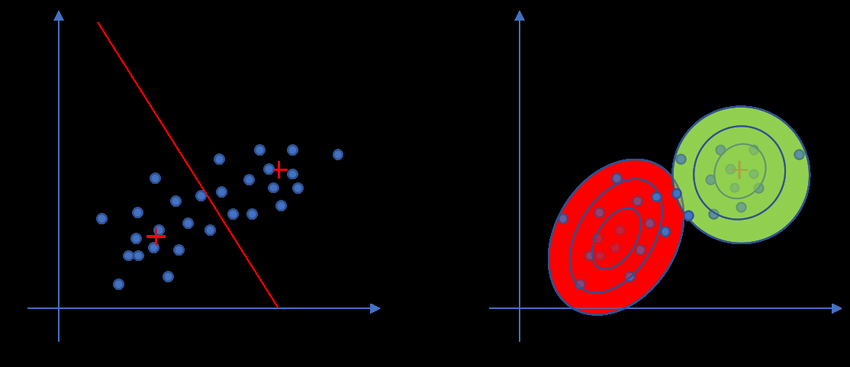

#Gaussian Mixture Model

###Gaussian Distribution
- normal/bell shaped curve where half of the data is falling on either sides of the graph.
- Symmetrical


###Gaussian Mixture
- GMM assumes data comes from multiple hidden behaviour patterns mixed together.

**Example**
- In canteen
   - Snack pattern(mean,variance,weight(population share))
      - 0.6 weight: 60% students behave like snack pattern
   - Meal pattern (mean,variance,weight(population share))
   - Premium pattern (mean,variance,weight(population share))

##Gaussian Mixture Model
- GMM is iterative, soft-clustering
- **EXPECTATION-MAXIMIZATION**
  - First Iteration(assign)
     - randomly initialize gaussian distribution(like centroids)
     - backend(for each data point, likehood is calculated)
    
  - Second Iteration(update)
     - convert likelihood to weight(dividing likelihood vector by its sum)
     - based on these, adjust mean and variance for Gaussian Distribution, changing the position

- Repeat until values stop changing
- Likelihood depends on:
  - Distance from mean
  - Variance/Covariance
  - Dimensionality
  - Normalization term

#GMM
- A Gaussian Mixture Model is a probabilistic clustering and density estimation method that assumes data is generated from multiple overlapping Gaussian distributions, not just one.
- Each Gaussian represents a hidden group in the data.

#Why do we need GMM?
- Real-world data rarely forms clean, well-separated clusters.
- GMM handles overlapping clusters and gives probability-based (soft) assignments, unlike K-Means which forces hard boundaries.

#Core Idea
1. Data is generated by K hidden sources (Gaussians).

2. Each data point belongs to all clusters with different probabilities.

3. The model learns:
 - Where clusters are (means),
 - How spread out they are (covariances),
 - How important each cluster is (weights).

#EM Algorithm
The Expectation–Maximization (EM) algorithm is used to train GMM.
- E-step (Expectation):
  - Estimate probabilities of each point belonging to each cluster.

- M-step (Maximization):
  - Update cluster parameters using those probabilities.

- These two steps repeat until the model stabilizes.

#Choosing Number of Clusters
- Elbow method
- Silhouette Score
- Cross Validation


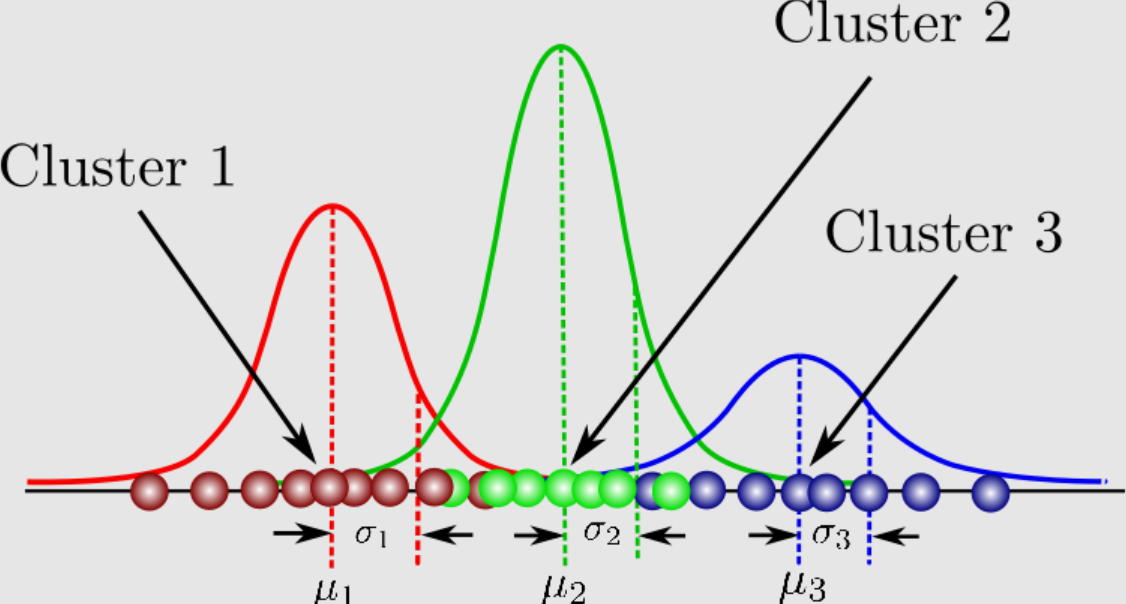

In [ ]:
# purchasing dataset: https://drive.google.com/file/d/1zLGXTxjs2YPhL7dOQ76e9239KaCfF6_O/view?usp=sharing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/purchasing.csv', encoding='latin')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175445 entries, 0 to 175444
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    175445 non-null  object 
 1   StockCode    175445 non-null  object 
 2   Description  174707 non-null  object 
 3   Quantity     175445 non-null  int64  
 4   InvoiceDate  175445 non-null  object 
 5   UnitPrice    175445 non-null  float64
 6   CustomerID   123156 non-null  float64
 7   Country      175444 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 10.7+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,738
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,52289
Country,1


In [ ]:
df.dropna(inplace=True)

In [ ]:
x=df.select_dtypes(include=[np.number])#float,int
x

,Quantity,UnitPrice,CustomerID
0,6,2.55,17850.0
1,6,3.39,17850.0
2,8,2.75,17850.0
3,6,3.39,17850.0
4,6,3.39,17850.0
...,...,...,...
175439,10,1.25,13883.0
175440,10,1.25,13883.0
175441,10,1.25,13883.0
175442,10,1.25,13883.0


In [ ]:
#standardization
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
x_scaled

array([[-0.0200605 , -0.02468049,  1.48306212],
       [-0.0200605 , -0.00543195,  1.48306212],
       [-0.01348537, -0.0200975 ,  1.48306212],
       ...,
       [-0.00691025, -0.05446989, -0.81181825],
       [-0.00691025, -0.05446989, -0.81181825],
       [-0.00691025, -0.05446989, -0.81181825]])

In [ ]:
#To identify number of categories/cluster/components
#- Elbow method
#- Silhouette Score

In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
#Initialize GMM
#n_components: number of clusters(elbow method to calculate clusters)
gmm=GaussianMixture(n_components=3, random_state=42)

gmm.fit(x_scaled)

GaussianMixture(n_components=3, random_state=42)

In [ ]:
#predict cluster labels
clusters=gmm.predict(x_scaled)
print(clusters)
df['Clusters']=clusters
df

[1 1 1 ... 0 0 0]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Clusters
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,1
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,1
...,...,...,...,...,...,...,...,...,...
175439,551958,22680,FRENCH BLUE METAL DOOR SIGN 5,10,5/5/2011 12:37,1.25,13883.0,United Kingdom,0
175440,551958,22679,FRENCH BLUE METAL DOOR SIGN 4,10,5/5/2011 12:37,1.25,13883.0,United Kingdom,0
175441,551958,22678,FRENCH BLUE METAL DOOR SIGN 3,10,5/5/2011 12:37,1.25,13883.0,United Kingdom,0
175442,551958,22677,FRENCH BLUE METAL DOOR SIGN 2,10,5/5/2011 12:37,1.25,13883.0,United Kingdom,0


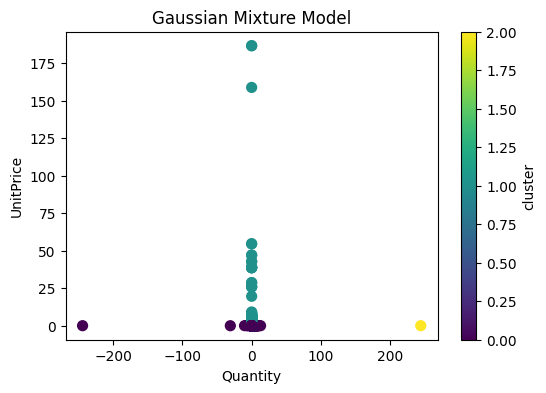

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(x_scaled[:,0],x_scaled[:,1], c=clusters, cmap='viridis', s=50)
plt.xlabel(x.columns[0])
plt.ylabel(x.columns[1])
plt.title("Gaussian Mixture Model")
plt.colorbar(label='cluster')
plt.show()

In [ ]:
#Cluster distribution
df['Clusters'].value_counts()

,count
Clusters,
1,79122
0,44033
2,1


In [ ]:
#3D visualization/ 2D for the whole data

## Comparison: K-Means vs Gaussian Mixture Model (GMM)

Both **K-Means** and **Gaussian Mixture Models (GMM)** are clustering algorithms, but they differ in how they form and assign clusters.

### K-Means Clustering
- Performs **hard clustering**
- Each data point belongs to **exactly one cluster**
- Uses **Euclidean distance** to assign points to the nearest centroid
- Assumes clusters are **spherical and of similar size**
- Simple and fast, but less flexible

### Gaussian Mixture Model (GMM)
- Performs **soft (probabilistic) clustering**
- Each data point has a **probability of belonging to each cluster**
- Assumes data is generated from a **mixture of Gaussian distributions**
- Can model **elliptical clusters with different sizes and shapes**
- More suitable for **real-world data with overlapping clusters**

---

## Why GMM for Purchasing Data?

Customer purchasing behavior often overlaps:
- A customer may behave like a **medium spender** most of the time
- Occasionally behave like a **high spender**

GMM captures this uncertainty using probabilities, whereas K-Means forces a hard assignment.

---

## How the Number of Components (`n_components`) Was Selected

### 1. Domain Knowledge
In purchasing data, customers are commonly segmented into:
- Low spenders
- Medium spenders
- High spenders

This naturally suggests:
- `n_components = 3`

---

## Summary

- **K-Means**: distance-based, hard clustering, simple but restrictive
- **GMM**: probability-based, soft clustering, flexible and realistic
- **`n_components`** chosen using domain knowledge
